<a href="https://colab.research.google.com/github/esttefiCarde/ActividadMineriaDatos/blob/main/Modelo_Canasta_EstephanyC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Base - Evaluación de Minería de Datos


### Estudiante 1

-  **Nombre: Estephany**
- **Apellido: Cardenas Catenacci**
- **Correo institucional: est.cardenas@duocuc.cl**

https://www.kaggle.com/datasets/arunsworkspace/retail-pos-dataset-for-market-basket-analysis

---

## Tema del Proyecto
El presente proyecto aplica técnicas de minería de datos sobre un dataset de ventas de supermercado.  
En esta primera parte se utilizará el modelo Market Basket Analysis, con el objetivo de identificar productos que suelen comprarse juntos dentro de una misma orden de compra.

---

## Descripción del Proyecto
El presente proyecto tiene como objetivo aplicar un modelo de **Market Basket Analysis** sobre un dataset de ventas de supermercado, con el fin de identificar patrones de compra entre los productos adquiridos por los clientes.

El problema principal consiste en descubrir qué productos suelen comprarse juntos dentro de una misma orden de compra. Para esto, se utilizarán los datos del archivo `Retail_pos_basket_data.csv.csv`, el cual contiene información de órdenes de compra, productos, categorías, cantidades, precios y horarios de venta.

Los actores involucrados en este análisis son principalmente el supermercado, los clientes y el área comercial o de marketing. El supermercado puede utilizar los resultados para tomar mejores decisiones sobre promociones, ubicación de productos, recomendaciones o creación de combos. Los clientes también se pueden ver beneficiados, ya que podrían recibir ofertas más relacionadas con sus hábitos de compra.

El modelo servirá para identificar asociaciones entre productos. Por ejemplo, si se detecta que ciertos productos se compran frecuentemente juntos, la empresa podría ubicarlos cerca dentro del local o generar promociones combinadas.

En esta primera parte del proyecto se utilizará el algoritmo **Apriori**, el cual permite encontrar conjuntos frecuentes de productos y generar reglas de asociación evaluadas mediante métricas como **soporte**, **confianza** y **lift**.


---

## Introducción a la Metodología

Este documento sigue la estructura de la metodología **CRISP-DM** (*Cross Industry Standard Process for Data Mining*), utilizada ampliamente para abordar proyectos de ciencia de datos y machine learning. Se compone de seis fases fundamentales:

---

## Fases de CRISP-DM

### 1. Comprensión del Negocio
Describa el objetivo del proyecto desde una perspectiva práctica o social. ¿Qué decisión se espera mejorar gracias al modelo?

---

### 2. Comprensión de los Datos
- Describa la fuente del dataset
- Número de registros y columnas
- Variables objetivo y predictoras
- Tipos de datos: numéricos, categóricos, fechas, etc.

---

### 3. Preparación de los Datos

#### a. Limpieza de Datos
- Eliminación o imputación de valores nulos
- Corrección de errores y outliers
- Revisión de duplicados

#### b. Transformaciones y Encoding
- Normalización, estandarización, escalamiento si aplica
- Codificación de variables categóricas (OneHotEncoding, LabelEncoder)
- Selección o ingeniería de características (feature selection/engineering)

---

### 4. Análisis Exploratorio de Datos
- Estadísticas descriptivas
- Visualizaciones significativas: histogramas, boxplots, gráficos de dispersión, mapas de calor, etc.
- Hipótesis o tendencias observadas

---

### 5. Modelado y Justificación

#### a. Tipo de problema
- ¿Se trata de clasificación o regresión?

#### b. Modelo(s) utilizados
- Algoritmo seleccionado (Regresión lineal, árbol de decisión, SVM, etc.)
- Justificación teórica y empírica del modelo
- Parámetros utilizados (si aplica)

---

### 6. Evaluación del Modelo
- División entrenamiento/prueba o validación cruzada
- Métricas reportadas:
  - Clasificación: Accuracy, Precision, Recall, F1-score
  - Regresión: RMSE, MAE, R²
- Análisis de errores y limitaciones

---

### 7. Conclusiones y Recomendaciones
- Interpretación de los resultados del modelo
- Limitaciones del análisis
- Propuestas de mejora o posibles extensiones del proyecto
- Aplicabilidad en un contexto real

---

## Recomendaciones Finales

- Documente cada etapa con claridad, justificando sus decisiones con fundamentos teóricos o exploratorios.
- Use visualizaciones para apoyar sus conclusiones.
- Acompañe su informe con código limpio y bien comentado.
- Recuerde que el proceso analítico y reflexivo es más valioso que lograr "el mejor modelo".

---



## 1. Comprensión del Negocio

El objetivo del proyecto es analizar las compras realizadas en un supermercado para identificar productos que suelen adquirirse juntos dentro de una misma orden. Para esto se aplicará el modelo **Market Basket Analysis**, utilizando reglas de asociación.

Desde una perspectiva práctica, este modelo puede ayudar al supermercado a mejorar decisiones comerciales, como la creación de promociones, recomendaciones de productos, organización de pasillos o ubicación estratégica de artículos dentro de la tienda.

La decisión que se espera mejorar gracias al modelo es la forma en que el supermercado ofrece y organiza sus productos. Por ejemplo, si el análisis muestra que ciertos productos se compran frecuentemente juntos, la empresa podría crear combos, descuentos o ubicar esos productos en zonas cercanas.

Este modelo sería útil principalmente para áreas de ventas, marketing y administración del supermercado, ya que permite comprender mejor el comportamiento de compra de los clientes.

In [140]:
# Instalación de librería necesaria para Market Basket Analysis
%pip install mlxtend -q

In [117]:
# Librerías para manejo y análisis de datos
import pandas as pd
import numpy as np

# Librerías para visualización
import matplotlib.pyplot as plt

# Librerías para Market Basket Analysis

from mlxtend.frequent_patterns import apriori, association_rules

df = pd.read_csv("Retail_pos_basket_data.csv.csv")


## 2. Comprensión de los Datos

El dataset utilizado corresponde a datos de ventas de un supermercado en formato POS, es decir, registros generados a partir de compras realizadas por clientes. El archivo utilizado se llama `Retail_pos_basket_data.csv.csv`.

El conjunto de datos contiene **10.000 registros** y **10 columnas**. Cada fila representa un producto comprado dentro de una orden. Por lo tanto, una misma orden puede aparecer en varias filas si el cliente compró más de un producto.

Las columnas del dataset son:

- `order_id`: identificador de la orden o compra.
- `user_id`: identificador del cliente.
- `order_date`: fecha de la compra.
- `time`: hora exacta de la compra.
- `order_hour_of_day`: hora del día en que se realizó la compra.
- `product_name`: nombre del producto comprado.
- `quantity`: cantidad comprada del producto.
- `price`: precio del producto.
- `category`: categoría del producto.
- `product_id`: identificador del producto.

Para el modelo Market Basket Analysis, las variables más importantes son:

- `order_id`, porque permite identificar cada canasta de compra.
- `product_name`, porque permite conocer qué productos fueron comprados dentro de cada orden.

En este caso no existe una variable objetivo como en un modelo supervisado, ya que Market Basket Analysis no busca predecir una variable específica, sino encontrar asociaciones entre productos.

El dataset contiene variables numéricas, categóricas y temporales. Las variables numéricas son `order_id`, `user_id`, `order_hour_of_day`, `quantity`, `price` y `product_id`. Las variables categóricas son `product_name` y `category`. Las variables temporales son `order_date` y `time`.

Además, el dataset cuenta con aproximadamente **1.991 órdenes únicas**, **488 clientes únicos**, **68 productos distintos** y **17 categorías de productos**.

In [118]:
# Información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   order_id           10000 non-null  int64  
 1   user_id            10000 non-null  int64  
 2   order_date         10000 non-null  object 
 3   time               10000 non-null  object 
 4   order_hour_of_day  10000 non-null  int64  
 5   product_name       10000 non-null  object 
 6   quantity           10000 non-null  int64  
 7   price              10000 non-null  float64
 8   category           10000 non-null  object 
 9   product_id         10000 non-null  int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 781.4+ KB


In [119]:
# Cantidad de filas y columnas
df.shape

(10000, 10)

In [120]:
# Cantidad de valores únicos por columna
df.nunique()

,0
order_id,1991
user_id,488
order_date,363
time,896
order_hour_of_day,17
product_name,68
quantity,3
price,9083
category,17
product_id,900


## 3. Preparación de los Datos
En esta etapa se preparan los datos para poder aplicar correctamente el modelo de Market Basket Analysis.

Como el objetivo del modelo es encontrar productos que suelen comprarse juntos, se utilizarán principalmente las columnas `order_id` y `product_name`.

La columna `order_id` permite identificar cada orden de compra, mientras que `product_name` indica los productos incluidos en cada orden. A partir de estas variables se podrá construir una canasta de productos por cada compra.

Además, se revisarán valores nulos, registros duplicados y tipos de datos.

In [121]:
# Copia del dataset original para trabajar la preparación de datos
df_limpio = df.copy()

# Visualizar las primeras filas
df_limpio.head()

,order_id,user_id,order_date,time,order_hour_of_day,product_name,quantity,price,category,product_id
0,1000,341,2024-09-04,15:43:00,15,Wheat Flour,1,333.44,Grains & Staples,457
1,1000,341,2024-09-04,15:43:00,15,Dishwashing Liquid,2,405.92,Household,745
2,1000,341,2024-09-04,15:43:00,15,Pastry,2,114.15,Bakery,849
3,1000,341,2024-09-04,15:43:00,15,Marker,2,171.33,Stationery,599
4,1001,324,2024-03-07,8:45:00,8,Saree,2,41.16,Clothing,329


In [122]:
# Revisar dimensiones del dataset
print("Cantidad de filas y columnas:", df_limpio.shape)

# Revisar nombres de columnas
print("Columnas del dataset:")
print(df_limpio.columns)

Cantidad de filas y columnas: (10000, 10)
Columnas del dataset:
Index(['order_id', 'user_id', 'order_date', 'time', 'order_hour_of_day',
       'product_name', 'quantity', 'price', 'category', 'product_id'],
      dtype='object')


In [123]:
# Revisar tipos de datos
df_limpio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   order_id           10000 non-null  int64  
 1   user_id            10000 non-null  int64  
 2   order_date         10000 non-null  object 
 3   time               10000 non-null  object 
 4   order_hour_of_day  10000 non-null  int64  
 5   product_name       10000 non-null  object 
 6   quantity           10000 non-null  int64  
 7   price              10000 non-null  float64
 8   category           10000 non-null  object 
 9   product_id         10000 non-null  int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 781.4+ KB



### 3.1 Depuración de Datos

En esta sección se revisan posibles problemas de calidad en los datos, como valores nulos, registros duplicados o inconsistencias.

Esta etapa es importante porque el modelo de reglas de asociación depende de que las órdenes y productos estén correctamente registrados. Si existieran valores vacíos en `order_id` o `product_name`, no sería posible construir correctamente las canastas de compra.

In [124]:
# Revisión de valores nulos por columna
df_limpio.isnull().sum()

,0
order_id,0
user_id,0
order_date,0
time,0
order_hour_of_day,0
product_name,0
quantity,0
price,0
category,0
product_id,0


In [125]:
# Revisión de registros duplicados
duplicados = df_limpio.duplicated().sum()

print("Cantidad de registros duplicados:", duplicados)

Cantidad de registros duplicados: 0


In [126]:
# Verificar valores nulos en las columnas principales para Market Basket Analysis
df_limpio[["order_id", "product_name"]].isnull().sum()

,0
order_id,0
product_name,0


In [127]:
# Cantidad de órdenes únicas y productos únicos
print("Órdenes únicas:", df_limpio["order_id"].nunique())
print("Productos únicos:", df_limpio["product_name"].nunique())
print("Categorías únicas:", df_limpio["category"].nunique())

Órdenes únicas: 1991
Productos únicos: 68
Categorías únicas: 17



### 3.2 Encoding

En esta etapa se aplicó un **encoding transaccional**, donde cada producto se convierte en una columna.

El valor `True` indica que el producto fue comprado en esa orden, mientras que `False` indica que no fue comprado.

Este formato es necesario para aplicar el algoritmo Apriori.


In [128]:
# Creación de matriz transaccional para Market Basket Analysis

# Se agrupan los datos por orden de compra y por producto.
# Esto permite saber qué productos aparecen dentro de cada orden.
basket = (
    df_limpio
    .groupby(["order_id", "product_name"])["quantity"]
    .sum()
    .unstack(fill_value=0)
)

# Para el algoritmo Apriori no interesa la cantidad exacta comprada,
# sino si el producto estuvo presente o no dentro de la orden.
# Por eso, los valores mayores que 0 se transforman en True,
# y los valores iguales a 0 se transforman en False.
basket_bool = basket > 0

# Muestra las dimensiones de la matriz transaccional.
# El primer número corresponde a la cantidad de órdenes.
# El segundo número corresponde a la cantidad de productos distintos.
print("Dimensiones de la matriz transaccional:", basket_bool.shape)

# Muestra las primeras filas de la matriz para verificar que la transformación se realizó correctamente.
display(basket_bool.head())

Dimensiones de la matriz transaccional: (1991, 68)


product_name,Apple,Baby Food,Banana,Beef,Belt,Biscuits,Bread,Butter,Cake,Carrot,...,Spinach,Sugar,Tea,Tissue,Toilet Paper,Tomato,Toothpaste,Vitamins,Wheat Flour,Yogurt
order_id,,,,,,,,,,,,,,,,,,,,,
1000,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1001,True,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
1002,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1003,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1004,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False


La matriz transaccional permite representar cada orden de compra como una fila y cada producto como una columna.  
Los valores `True` indican que el producto fue comprado en esa orden, mientras que los valores `False` indican que no fue comprado.

Esta transformación es necesaria para aplicar el algoritmo Apriori, ya que este modelo trabaja con la presencia o ausencia de productos dentro de cada transacción.


## 4. Análisis Exploratorio

En esta sección se realiza un análisis descriptivo del dataset antes de aplicar el modelo Market Basket Analysis.

Se revisan los productos más vendidos, las categorías principales, los horarios de compra y el tamaño de las órdenes. Esto permite comprender mejor el comportamiento general de compra de los clientes.

# 4.1 Productos más vendidos

,Cantidad vendida
product_name,
Soda,347
Prawns,338
Energy Drink,335
Shoes,334
Face Wash,331
Chocolate,330
Dishwashing Liquid,325
Toilet Paper,324
Milk,323


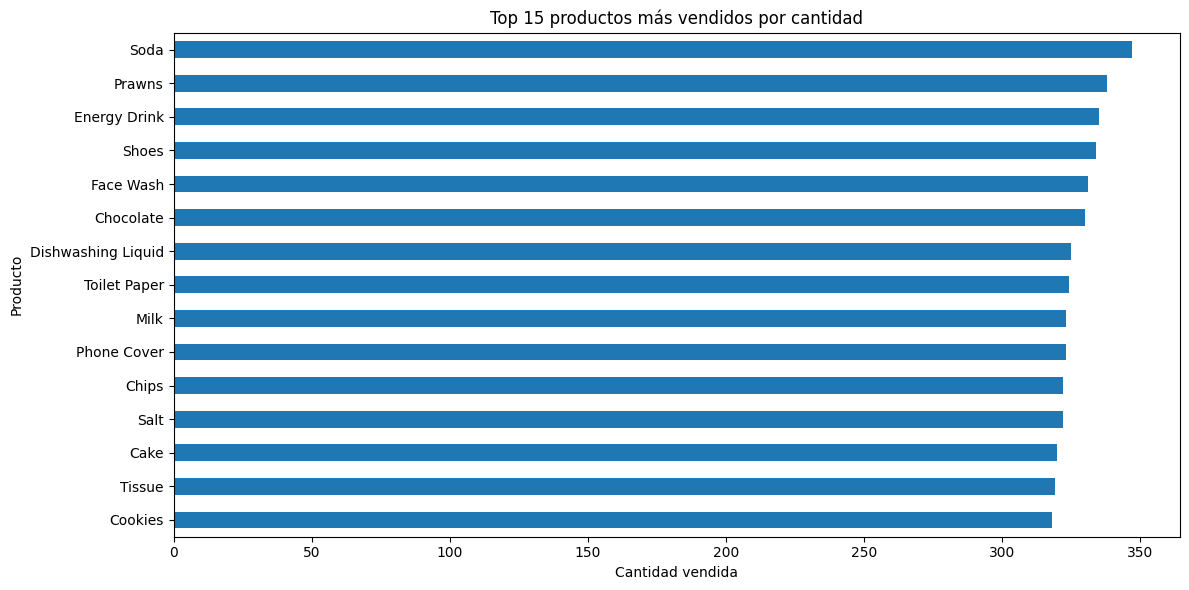

In [129]:
# Productos más vendidos por cantidad total

# Se agrupa el dataset por nombre de producto.
# Luego se suma la cantidad vendida de cada producto.
# Finalmente, se ordenan los productos de mayor a menor y se seleccionan los 15 principales.
productos_mas_vendidos = (
    df_limpio.groupby("product_name")["quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

# Se muestra la tabla con los productos más vendidos
display(productos_mas_vendidos.to_frame("Cantidad vendida"))

# Se crea un gráfico de barras horizontal
plt.figure(figsize=(12, 6))

# Se ordenan los valores para que el gráfico se vea de menor a mayor
productos_mas_vendidos.sort_values().plot(kind="barh")

# Título y etiquetas del gráfico
plt.title("Top 15 productos más vendidos por cantidad")
plt.xlabel("Cantidad vendida")
plt.ylabel("Producto")

# Ajusta el gráfico para que no se corten los nombres
plt.tight_layout()

# Muestra el gráfico
plt.show()

El gráfico muestra los 15 productos con mayor cantidad vendida dentro del dataset. Este análisis permite identificar cuáles son los productos con mayor demanda en el supermercado.

# 4.2 Categorías más frecuentes

,Cantidad vendida
category,
Grains & Staples,2359
Fruits & Vegetables,2326
Bakery,1545
Household,1523
Beverages,1519
Dairy & Eggs,1488
Electronics,1448
Snacks,1246
Meat & Seafood,1206


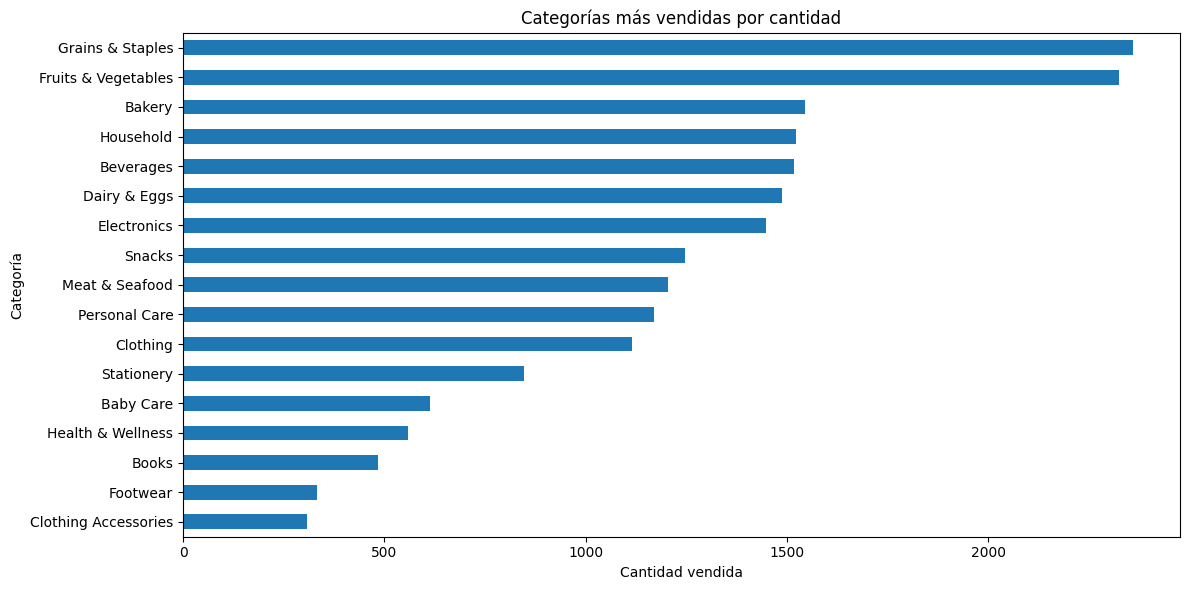

In [130]:
# Categorías más frecuentes por cantidad vendida

# Se agrupan los datos por categoría.
# Luego se suma la cantidad vendida en cada categoría.
categorias_mas_vendidas = (
    df_limpio.groupby("category")["quantity"]
    .sum()
    .sort_values(ascending=False)
)

# Se muestra la tabla de categorías
display(categorias_mas_vendidas.to_frame("Cantidad vendida"))

# Gráfico de barras
plt.figure(figsize=(12, 6))
categorias_mas_vendidas.sort_values().plot(kind="barh")

plt.title("Categorías más vendidas por cantidad")
plt.xlabel("Cantidad vendida")
plt.ylabel("Categoría")
plt.tight_layout()
plt.show()

Este gráfico muestra las categorías de productos con mayor cantidad vendida. Sirve para conocer qué tipos de productos tienen mayor presencia dentro de las compras realizadas.

# 4.3 Compras por hora del día

,Cantidad de órdenes
order_hour_of_day,
6,128
7,131
8,125
9,113
10,107
11,132
12,119
13,110
14,108


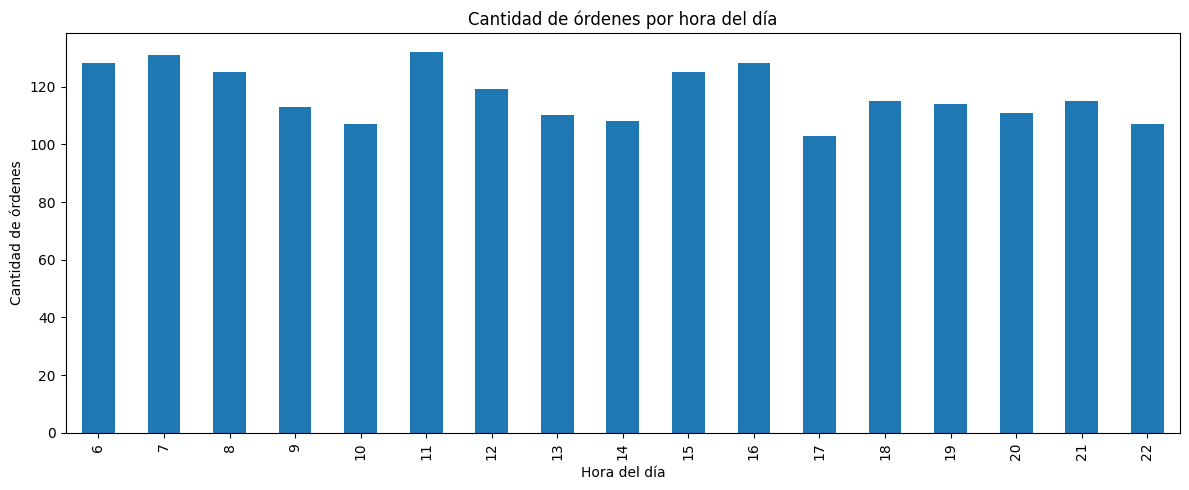

In [131]:
# Cantidad de órdenes por hora del día

# Se agrupan los datos por hora del día.
# Para evitar contar varias veces una misma orden, se usa nunique() sobre order_id.
compras_por_hora = (
    df_limpio.groupby("order_hour_of_day")["order_id"]
    .nunique()
)

# Se muestra la tabla
display(compras_por_hora.to_frame("Cantidad de órdenes"))

# Gráfico de barras
plt.figure(figsize=(12, 5))
compras_por_hora.plot(kind="bar")

plt.title("Cantidad de órdenes por hora del día")
plt.xlabel("Hora del día")
plt.ylabel("Cantidad de órdenes")
plt.tight_layout()
plt.show()

Este gráfico permite identificar en qué horarios se concentran más órdenes de compra. Aunque esta variable no se utiliza directamente en Apriori, ayuda a comprender el comportamiento general de los clientes.

# 4.4 Tamaño de las órdenes

,Productos por orden
count,1991.000000
mean,4.872426
std,1.383608
min,2.000000
25%,4.000000
50%,5.000000
75%,6.000000
max,7.000000


,Cantidad de órdenes
product_name,
2,19
3,403
4,410
5,455
6,389
7,315


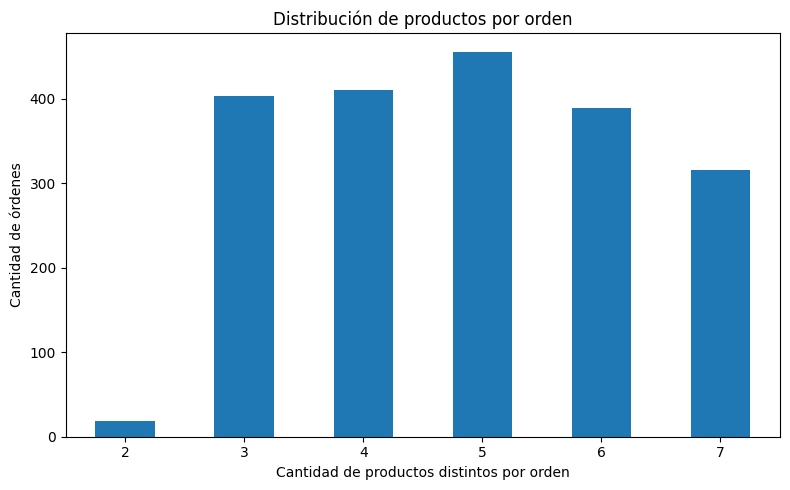

In [132]:


# Se agrupa el dataset por orden de compra.
# Luego se cuenta cuántos productos distintos tiene cada orden.
# Esto permite conocer el tamaño de cada canasta de compra.
productos_por_orden = (
    df_limpio
    .groupby("order_id")["product_name"]
    .nunique()
)

# Se muestran estadísticas descriptivas del tamaño de las canastas.
# count: cantidad de órdenes analizadas.
# mean: promedio de productos distintos por orden.
# min: mínimo de productos distintos en una orden.
# max: máximo de productos distintos en una orden.
display(productos_por_orden.describe().to_frame("Productos por orden"))

# Se cuenta cuántas órdenes tienen una cierta cantidad de productos distintos.
# Por ejemplo: cuántas órdenes tienen 2 productos, cuántas tienen 3, etc.
distribucion_productos = productos_por_orden.value_counts().sort_index()

# Se muestra una tabla resumen con la cantidad de órdenes según el número de productos.
display(distribucion_productos.to_frame("Cantidad de órdenes"))

# Se define el tamaño del gráfico.
plt.figure(figsize=(8, 5))

# Se crea un gráfico de barras para visualizar la distribución.
# Cada barra representa una cantidad de productos distintos por orden.
distribucion_productos.plot(kind="bar")

# Se agrega el título del gráfico.
plt.title("Distribución de productos por orden")

# Se agrega la etiqueta del eje X.
plt.xlabel("Cantidad de productos distintos por orden")

# Se agrega la etiqueta del eje Y.
plt.ylabel("Cantidad de órdenes")

# Se deja el texto del eje X en posición horizontal para que se vea más claro.
plt.xticks(rotation=0)

# Se ajusta el diseño para evitar que se corten textos o etiquetas.
plt.tight_layout()

# Se muestra el gráfico final.
plt.show()

Este análisis muestra cuántos productos distintos suelen incluir las órdenes de compra. Es relevante porque Market Basket Analysis necesita transacciones con más de un producto para poder encontrar asociaciones entre artículos.

# 4.5 Productos más frecuentes por aparición en órdenes

,Órdenes en las que aparece
product_name,
Dishwashing Liquid,163
Chips,161
Cake,158
Energy Drink,158
Soda,158
Prawns,157
Tissue,157
Phone Cover,156
Milk,155


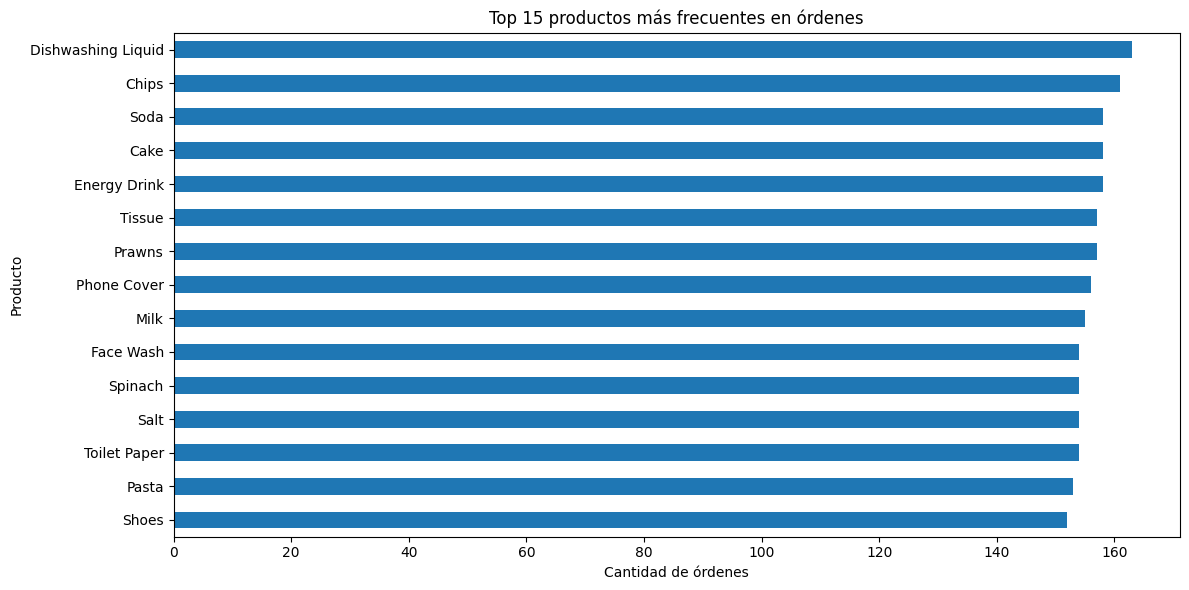

In [133]:
# Productos que aparecen en más órdenes

# Se agrupa por producto y se cuenta en cuántas órdenes distintas aparece.
productos_frecuentes = (
    df_limpio.groupby("product_name")["order_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(15)
)

# Mostrar tabla
display(productos_frecuentes.to_frame("Órdenes en las que aparece"))

# Gráfico
plt.figure(figsize=(12, 6))
productos_frecuentes.sort_values().plot(kind="barh")

plt.title("Top 15 productos más frecuentes en órdenes")
plt.xlabel("Cantidad de órdenes")
plt.ylabel("Producto")
plt.tight_layout()
plt.show()

Este gráfico muestra los productos que aparecen en una mayor cantidad de órdenes. Esta información es especialmente útil para Market Basket Analysis, ya que el algoritmo Apriori trabaja con la presencia o ausencia de productos dentro de cada transacción.

## 5. Modelado

En esta primera parte del proyecto se utiliza el modelo **Market Basket Analysis**, específicamente mediante el algoritmo **Apriori** y reglas de asociación.

Este modelo no corresponde a un problema de clasificación ni de regresión, ya que no busca predecir una variable objetivo. En cambio, corresponde a una técnica de **aprendizaje no supervisado**, porque permite descubrir patrones ocultos dentro de las transacciones sin tener una variable dependiente previamente definida.

El objetivo del modelo es identificar productos que suelen comprarse juntos dentro de una misma orden de compra. Para esto, se utiliza la matriz transaccional construida anteriormente, donde cada fila representa una orden y cada columna representa un producto.

El algoritmo Apriori permite encontrar conjuntos frecuentes de productos, y posteriormente se generan reglas de asociación evaluadas mediante métricas como soporte, confianza y lift.

# 5.1 Aplicación del algoritmo Apriori

In [134]:


# Apriori busca conjuntos frecuentes de productos dentro de las órdenes.
# min_support=0.005 significa que se considerarán combinaciones que aparecen
# al menos en el 0,5% de las órdenes.
frequent_itemsets = apriori(
    basket_bool,
    min_support=0.005,
    use_colnames=True
)

# Se crea una columna para saber cuántos productos tiene cada conjunto frecuente.
# Por ejemplo:
# length = 1 significa un producto individual.
# length = 2 significa una combinación de dos productos.
frequent_itemsets["length"] = frequent_itemsets["itemsets"].apply(lambda x: len(x))

# Se ordenan los resultados primero por cantidad de productos
# y luego por soporte de mayor a menor.
frequent_itemsets = frequent_itemsets.sort_values(
    by=["length", "support"],
    ascending=[True, False]
).reset_index(drop=True)

# Se muestra la cantidad total de itemsets frecuentes encontrados
print("Cantidad de itemsets frecuentes encontrados:", len(frequent_itemsets))

# Se muestran los primeros 20 resultados
display(frequent_itemsets.head(20))

Cantidad de itemsets frecuentes encontrados: 1034


,support,itemsets,length
0,0.081868,(Dishwashing Liquid),1
1,0.080864,(Chips),1
2,0.079357,(Cake),1
3,0.079357,(Energy Drink),1
4,0.079357,(Soda),1
5,0.078855,(Prawns),1
6,0.078855,(Tissue),1
7,0.078353,(Phone Cover),1
8,0.077850,(Milk),1
9,0.077348,(Face Wash),1


Los resultados muestran los itemsets frecuentes encontrados por el algoritmo Apriori. En las primeras filas se observan productos individuales, ya que poseen `length = 1`.

El producto con mayor soporte es `Dishwashing Liquid`, con un soporte aproximado de 0,0819. Esto significa que aparece en cerca del 8,19% de las órdenes de compra. También destacan productos como `Chips`, `Cake`, `Energy Drink` y `Soda`, los cuales presentan soportes cercanos al 8%.

En total, el algoritmo encontró 1.034 itemsets frecuentes utilizando un soporte mínimo de 0,005. Esto significa que se consideraron frecuentes aquellos productos o combinaciones que aparecen en al menos el 0,5% de las órdenes.

In [135]:
# Itemsets frecuentes con más de un producto

# Se filtran los itemsets frecuentes para conservar solo aquellos
# que tienen más de un producto.
# Estos son los más importantes para Market Basket Analysis,
# porque muestran productos que aparecen juntos dentro de una misma orden.
itemsets_multiples = frequent_itemsets[
    frequent_itemsets["length"] > 1
].copy()

# Se muestra la cantidad de itemsets frecuentes con más de un producto
print(
    "Cantidad de itemsets frecuentes con más de un producto:",
    len(itemsets_multiples)
)

# Se ordenan las combinaciones por soporte de mayor a menor
# y se muestran las primeras 20.
display(
    itemsets_multiples
    .sort_values("support", ascending=False)
    .head(20)
)

Cantidad de itemsets frecuentes con más de un producto: 966


,support,itemsets,length
69,0.009543,"(Detergent, Earphones)",2
68,0.009543,"(Milk, Butter)",2
75,0.009041,"(Energy Drink, Tomato)",2
74,0.009041,"(Sugar, Energy Drink)",2
73,0.009041,"(Saree, Cooking Oil)",2
70,0.009041,"(Milk, Baby Food)",2
71,0.009041,"(Bread, Pastry)",2
72,0.009041,"(Cheese, Chips)",2
76,0.009041,"(Spices, Shoes)",2
85,0.008538,"(Vitamins, Soda)",2


En esta parte se filtraron los itemsets frecuentes para conservar solo aquellos que contienen más de un producto. Estos resultados son especialmente relevantes para Market Basket Analysis, ya que permiten identificar combinaciones de productos que aparecen juntas dentro de las órdenes de compra.

A diferencia de los itemsets individuales, los itemsets múltiples ayudan a observar asociaciones entre productos, lo cual posteriormente permite generar reglas del tipo `Producto A → Producto B`.

# 5.2 Generación de reglas de asociación

In [136]:


# A partir de los itemsets frecuentes se generan reglas de asociación.
# Se utiliza la métrica confidence con un umbral mínimo de 0.10.
# Esto significa que se conservarán reglas con al menos 10% de confianza.
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.10
)

# Conversión de antecedentes y consecuentes a texto para facilitar la lectura.
# Originalmente vienen como frozenset, por eso se transforman a texto.
rules["antecedents_txt"] = rules["antecedents"].apply(lambda x: ", ".join(list(x)))
rules["consequents_txt"] = rules["consequents"].apply(lambda x: ", ".join(list(x)))

# Ordenar reglas por lift, confianza y soporte.
# Lift permite identificar las asociaciones más fuertes.
# Confidence permite revisar qué tan probable es el consecuente dado el antecedente.
# Support permite revisar qué tan frecuente es la regla en el total de órdenes.
rules_ordenadas = rules.sort_values(
    by=["lift", "confidence", "support"],
    ascending=False
).reset_index(drop=True)

# Selección de columnas principales para interpretar las reglas.
columnas_reglas = [
    "antecedents_txt",
    "consequents_txt",
    "support",
    "confidence",
    "lift",
    "leverage",
    "conviction"
]

# Mostrar cantidad de reglas generadas
print("Cantidad de reglas generadas:", len(rules_ordenadas))

# Mostrar las primeras 20 reglas ordenadas
display(rules_ordenadas[columnas_reglas].head(20))

Cantidad de reglas generadas: 184


,antecedents_txt,consequents_txt,support,confidence,lift,leverage,conviction
0,Juice,Shirt,0.007534,0.115385,1.930511,0.003631,1.062870
1,Shirt,Juice,0.007534,0.126050,1.930511,0.003631,1.069520
2,Educational Book,Croissant,0.008036,0.136752,1.890788,0.003786,1.074633
3,Croissant,Educational Book,0.008036,0.111111,1.890788,0.003786,1.058890
4,Earphones,Detergent,0.009543,0.131944,1.850010,0.004385,1.069838
5,Detergent,Earphones,0.009543,0.133803,1.850010,0.004385,1.070974
6,Charger,Vitamins,0.008036,0.125984,1.844372,0.003679,1.065991
7,Vitamins,Charger,0.008036,0.117647,1.844372,0.003679,1.061041
8,Shirt,Jeans,0.007534,0.126050,1.779903,0.003301,1.063198
9,Jeans,Shirt,0.007534,0.106383,1.779903,0.003301,1.052163


El modelo generó 184 reglas de asociación. Estas reglas muestran relaciones entre productos que aparecen juntos dentro de una misma orden de compra.

Las reglas fueron ordenadas principalmente por la métrica `lift`, ya que esta permite identificar asociaciones más fuertes entre productos. En este caso, todas las primeras reglas presentan un lift mayor a 1, lo que indica una asociación positiva entre los productos.

Por ejemplo, la regla `Juice → Shirt` presenta un soporte de 0,0075, una confianza de 0,1154 y un lift de 1,9305. Esto significa que la combinación aparece en aproximadamente el 0,75% de las órdenes, y que cuando aparece `Juice`, existe un 11,54% de probabilidad de que también aparezca `Shirt`. El lift de 1,93 indica que ambos productos aparecen juntos casi el doble de lo esperado.

Otra regla relevante es `Educational Book → Croissant`, con un lift de 1,8908. Esto indica que estos productos también presentan una asociación positiva dentro de las órdenes analizadas.

En general, las reglas obtenidas permiten identificar patrones de compra que podrían ser utilizados para generar recomendaciones, promociones combinadas o decisiones sobre la ubicación de productos.

## 6. Entrenamiento y Evaluación

En este modelo no existe un entrenamiento tradicional como ocurre en modelos supervisados, por ejemplo regresión o clasificación. En Market Basket Analysis se trabaja con aprendizaje no supervisado, por lo que el modelo no aprende a predecir una variable objetivo, sino que identifica patrones frecuentes dentro de las órdenes de compra.

La evaluación del modelo se realiza mediante las métricas obtenidas en las reglas de asociación. Las principales métricas utilizadas son:

- **Support:** indica qué tan frecuente aparece una combinación de productos dentro del total de órdenes.
- **Confidence:** indica la probabilidad de que aparezca el producto consecuente cuando ya apareció el producto antecedente.
- **Lift:** indica la fuerza de la relación entre los productos. Un valor mayor a 1 representa una asociación positiva.
- **Leverage:** mide cuánto más aparece una combinación respecto a lo que se esperaría si los productos fueran independientes.
- **Conviction:** mide la dependencia entre antecedente y consecuente. Valores mayores a 1 indican una relación más fuerte.



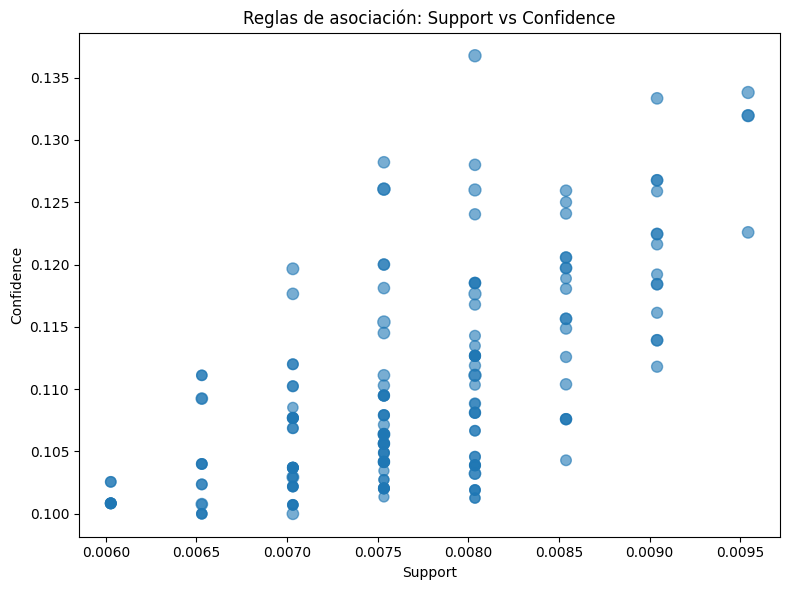

In [137]:
# Visualización de reglas: support vs confidence, con tamaño según lift

# Se verifica que existan reglas generadas antes de graficar.
if len(rules_ordenadas) > 0:

    # Crear figura del gráfico
    plt.figure(figsize=(8, 6))

    # Crear gráfico de dispersión
    # Eje X: support, frecuencia de la regla en el total de órdenes
    # Eje Y: confidence, probabilidad del consecuente dado el antecedente
    # Tamaño del punto: lift, fuerza de la asociación
    plt.scatter(
        rules_ordenadas["support"],
        rules_ordenadas["confidence"],
        s=rules_ordenadas["lift"] * 40,
        alpha=0.6
    )

    # Título y etiquetas del gráfico
    plt.title("Reglas de asociación: Support vs Confidence")
    plt.xlabel("Support")
    plt.ylabel("Confidence")

    # Ajustar diseño
    plt.tight_layout()

    # Mostrar gráfico
    plt.show()

else:
    print("No se generaron reglas con los umbrales actuales.")

El gráfico muestra la relación entre `support` y `confidence` de las reglas de asociación generadas. Cada punto representa una regla.

En el eje X se observa el soporte, que indica qué tan frecuente aparece la combinación de productos dentro del total de órdenes. En el eje Y se observa la confianza, que indica la probabilidad de que aparezca el consecuente cuando ya aparece el antecedente.

Además, el tamaño de los puntos está relacionado con el `lift`, por lo que los puntos más grandes representan reglas con una asociación más fuerte entre productos.

En general, se observa que las reglas tienen soportes bajos, entre aproximadamente 0,006 y 0,0095. Esto significa que las combinaciones de productos no aparecen en una gran parte de las órdenes, pero sí cumplen con el mínimo definido para el análisis. Las confianzas se encuentran aproximadamente entre 0,10 y 0,137, lo que indica que algunas reglas tienen una probabilidad moderada de ocurrencia.

Las 10 reglas principales fueron ordenadas por `lift`, `confidence` y `support`. La regla con mayor lift fue `Juice → Shirt`, con un lift de 1,9305. Esto indica que estos productos aparecen juntos casi 1,93 veces más de lo esperado si fueran independientes.

También se observan reglas como `Educational Book → Croissant`, `Earphones → Detergent` y `Charger → Vitamins`, todas con lift mayor a 1. Esto significa que existe una asociación positiva entre esos productos dentro del dataset.

In [138]:
# Top 10 reglas según lift

# Como rules_ordenadas ya fue ordenado por lift, confidence y support,
# se seleccionan las primeras 10 reglas más relevantes.
top_10_reglas = rules_ordenadas[columnas_reglas].head(10).copy()

# Mostrar las 10 reglas principales
display(top_10_reglas)

,antecedents_txt,consequents_txt,support,confidence,lift,leverage,conviction
0,Juice,Shirt,0.007534,0.115385,1.930511,0.003631,1.062870
1,Shirt,Juice,0.007534,0.126050,1.930511,0.003631,1.069520
2,Educational Book,Croissant,0.008036,0.136752,1.890788,0.003786,1.074633
3,Croissant,Educational Book,0.008036,0.111111,1.890788,0.003786,1.058890
4,Earphones,Detergent,0.009543,0.131944,1.850010,0.004385,1.069838
5,Detergent,Earphones,0.009543,0.133803,1.850010,0.004385,1.070974
6,Charger,Vitamins,0.008036,0.125984,1.844372,0.003679,1.065991
7,Vitamins,Charger,0.008036,0.117647,1.844372,0.003679,1.061041
8,Shirt,Jeans,0.007534,0.126050,1.779903,0.003301,1.063198
9,Jeans,Shirt,0.007534,0.106383,1.779903,0.003301,1.052163


## 7. Despliegue

En esta etapa se describe cómo podrían utilizarse los resultados obtenidos por el modelo **Market Basket Analysis** en un contexto real.

El modelo permitió identificar asociaciones entre productos dentro de las órdenes de compra. Estas reglas pueden servir como apoyo para la toma de decisiones comerciales en una tienda o supermercado, especialmente en áreas como ventas, marketing, administración de productos y experiencia del cliente.

A partir de las reglas generadas, la empresa podría utilizar los resultados para:

1. **Crear promociones combinadas:**  
   Si dos productos aparecen juntos con frecuencia, se podrían ofrecer descuentos o combos para incentivar la compra de ambos productos.

2. **Mejorar la ubicación de productos en tienda:**  
   Los productos asociados podrían ubicarse en zonas cercanas para facilitar la compra y aumentar las ventas cruzadas.

3. **Realizar recomendaciones de productos:**  
   En una tienda online o sistema de ventas, cuando un cliente agregue un producto al carrito, se le podrían sugerir otros productos relacionados según las reglas encontradas.

4. **Diseñar estrategias de venta cruzada:**  
   Las reglas pueden ayudar a identificar oportunidades para ofrecer productos complementarios al cliente.

5. **Analizar patrones de comportamiento de compra:**  
   El modelo permite comprender mejor qué productos tienden a comprarse juntos y cómo se comportan las canastas de los clientes.

En este caso, algunas reglas obtenidas fueron `Juice → Shirt`, `Educational Book → Croissant`, `Earphones → Detergent` y `Charger → Vitamins`. Estas asociaciones presentan valores de `lift` mayores a 1, por lo que indican una relación positiva entre los productos.

Sin embargo, para aplicar estos resultados en una decisión comercial real, es importante considerar que algunas reglas tienen soporte bajo. Esto significa que, aunque la asociación sea positiva, la combinación no aparece en una gran cantidad de órdenes. Por esta razón, las reglas deben analizarse considerando en conjunto las métricas `support`, `confidence` y `lift`.

Además, como el dataset contiene productos de categorías variadas, algunas asociaciones pueden parecer poco intuitivas. Por esto, sería recomendable complementar el análisis con información adicional, como categoría del producto, tipo de cliente, temporada, sucursal o canal de venta.

En resumen, el despliegue del modelo permitiría transformar los patrones encontrados en acciones comerciales concretas, como promociones, recomendaciones y mejoras en la organización de productos.

## 8. Conclusiones

A partir del desarrollo de Market Basket Analysis aplicado al dataset `Retail_pos_basket_data.csv.csv`, se concluye lo siguiente:

1. El dataset utilizado es adecuado para este modelo, ya que permite identificar los productos comprados dentro de una misma orden mediante las columnas `order_id` y `product_name`. Esto hizo posible construir canastas de compra reales para aplicar reglas de asociación.

2. El análisis exploratorio permitió conocer mejor el comportamiento general de las ventas. Se revisaron productos con mayor presencia, categorías principales, horarios de compra y distribución del tamaño de las canastas. Además, se observó que las órdenes contienen entre 2 y 7 productos distintos, lo cual es útil para aplicar Market Basket Analysis.

3. La transformación transaccional permitió convertir el dataset original en una matriz donde cada fila representa una orden y cada columna representa un producto. En esta matriz, los valores `True` y `False` indican la presencia o ausencia de cada producto dentro de una compra.

4. El algoritmo Apriori permitió encontrar 1034 itemsets frecuentes, considerando un soporte mínimo de 0.005. Esto significa que se identificaron productos individuales y combinaciones de productos que aparecen repetidamente dentro de las órdenes.

5. A partir de los itemsets frecuentes se generaron 184 reglas de asociación. Estas reglas fueron evaluadas mediante métricas como `support`, `confidence`, `lift`, `leverage` y `conviction`.

6. Entre las reglas más destacadas se encontraron asociaciones como `Juice → Shirt`, `Educational Book → Croissant`, `Earphones → Detergent` y `Charger → Vitamins`. Estas reglas presentan valores de `lift` mayores a 1, lo que indica una asociación positiva entre los productos, es decir, que aparecen juntos con mayor frecuencia de lo esperado.

7. Es importante considerar que algunas reglas tienen un soporte bajo, por lo que no representan a la mayoría de las órdenes. Por esta razón, las reglas deben interpretarse considerando en conjunto `support`, `confidence` y `lift`, y no solamente una métrica aislada.

8. En un contexto real, los resultados podrían apoyar decisiones comerciales como promociones combinadas, recomendaciones de productos, ubicación estratégica de artículos en tienda y estrategias de venta cruzada.

Como trabajo futuro, se recomienda complementar este análisis con más datos históricos, segmentar las reglas por categoría de producto o tipo de cliente, e incorporar variables como fecha, temporada o sucursal.

In [139]:
# Resumen final de resultados principales

print("RESUMEN FINAL")
print("Cantidad de registros:", len(df_limpio))
print("Cantidad de órdenes únicas:", df_limpio["order_id"].nunique())
print("Cantidad de clientes únicos:", df_limpio["user_id"].nunique())
print("Cantidad de productos únicos:", df_limpio["product_name"].nunique())
print("Cantidad de categorías únicas:", df_limpio["category"].nunique())
print("Cantidad de itemsets frecuentes:", len(frequent_itemsets))
print("Cantidad de reglas generadas:", len(rules_ordenadas))

RESUMEN FINAL
Cantidad de registros: 10000
Cantidad de órdenes únicas: 1991
Cantidad de clientes únicos: 488
Cantidad de productos únicos: 68
Cantidad de categorías únicas: 17
Cantidad de itemsets frecuentes: 1034
Cantidad de reglas generadas: 184
